####Univariate linear regression####

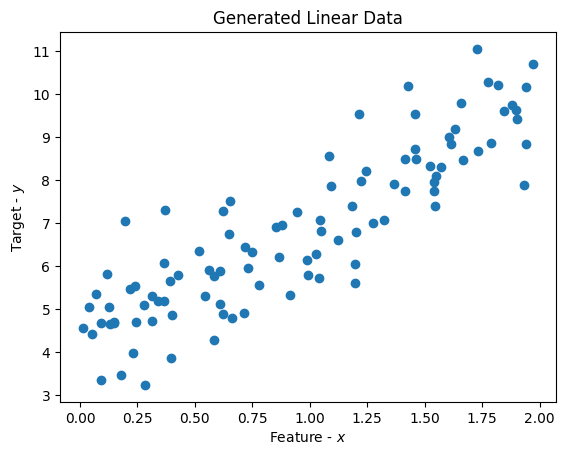

In [23]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate synthetic data (for simplicity)
np.random.seed(42)
x = 2 * np.random.rand(100, 1)  # 100 random points in the range [0, 2)
y = 4 + 3 * X + np.random.randn(100, 1)  # Linear relation with some noise

# Visualize the data
plt.scatter(x, y)
plt.xlabel("Feature - $x$")
plt.ylabel("Target - $y$")
plt.title("Generated Linear Data")
plt.show()


Define the model, $\widehat{y} = w_0 + w_1x$

In [24]:
# Step 2: Define the model and the cost function
def h(x,w):
    return x.dot(w)

# Cost function (Mean Squared Error)
def J(x, y, w):
    m = len(y)
    y_hat = h(x, w)
    cost = (1 / (2 * m)) * np.sum(np.square(y_hat - y))
    return cost

Implement Gradient Descent

In [25]:
# Step 3: Implement gradient descent
def gradient_descent(x, y, w, alpha, epochs):
    m = len(y)
    cost_history = np.zeros(epochs)

    for epoch in range(epochs):
        y_hat = h(x, w)
        gradient = (1 / m) * x.T.dot(y_hat - y)
        w = w - alpha * gradient

        # Store the cost at each epoch
        cost_history[epoch] = J(x, y, w)

    return w, cost_history


Prepare the data (Add a bias term to X)

In [26]:
# Step 4: Add a bias term (column of ones) to X
x_b = np.c_[np.ones((x.shape[0], 1)), x]  # Add a bias (intercept) term to the input features
# Initialize theta (parameters)
w_init = np.random.randn(2, 1)  # Random initialization of the parameters


Train the model using gradient descent

In [35]:
# Step 5: Train the model using gradient descent
alpha = 0.1
epochs = 50

w_opt, cost_history = gradient_descent(x_b, y, w_init, alpha, epochs)

# Display the optimal parameters (theta values)
print(f"Optimal parameters (w): {w_opt}")


Optimal parameters (w): [[3.48928119]
 [3.41092085]]


Visualize the cost function convergence

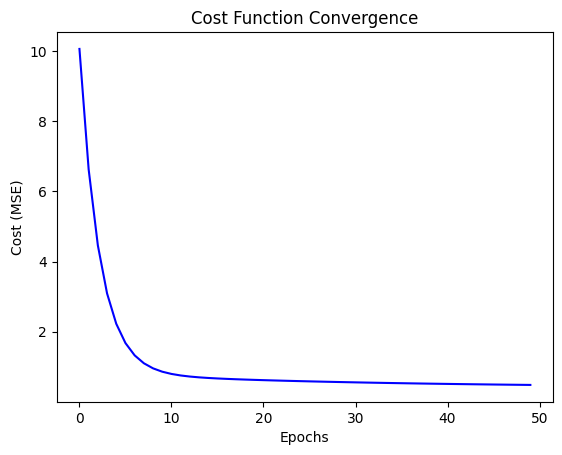

In [36]:
# Step 6: Plot the cost function convergence over epochs
plt.plot(range(epochs), cost_history, color='blue')
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Cost Function Convergence")
plt.show()

Evaluate the model on test data

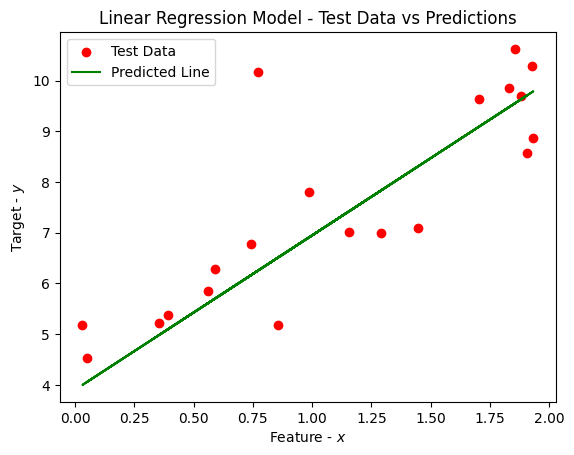

In [29]:
x_test = 2 * np.random.rand(20, 1)
y_test = 4 + 3 * x_test + np.random.randn(20, 1)

# Add a bias term to X_test
x_test_b = np.c_[np.ones((x_test.shape[0], 1)), x_test]

# Make predictions on the test set
y_pred = h(x_test_b, w_opt)

# Visualize the test data and predictions
plt.scatter(x_test, y_test, color='red', label='Test Data')
plt.plot(x_test, y_pred, color='green', label='Predicted Line')
plt.xlabel("Feature - $x$")
plt.ylabel("Target - $y$")
plt.title("Linear Regression Model - Test Data vs Predictions")
plt.legend()
plt.show()


##The same example using python packages##

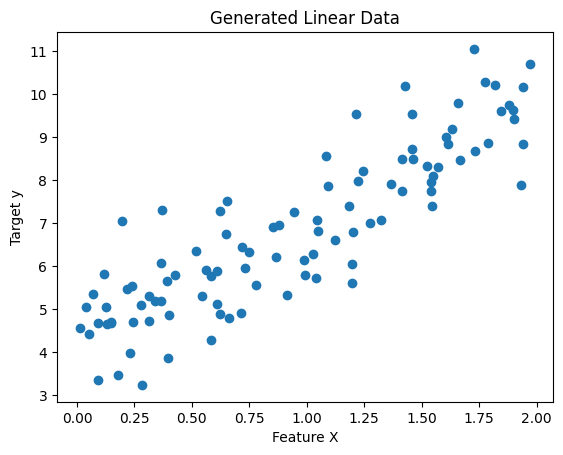

In [30]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 1: Generate synthetic data (same as before)
np.random.seed(42)
X = 2 * np.random.rand(100, 1)  # 100 random points in the range [0, 2)
y = 4 + 3 * X + np.random.randn(100, 1)  # Linear relation with some noise

# Visualize the data
plt.scatter(X, y)
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.title("Generated Linear Data")
plt.show()


Split the data into training and testing sets

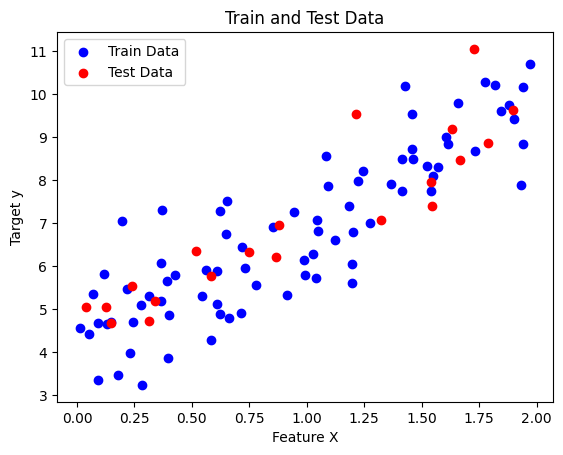

In [31]:
# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize the training data and test data
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.title("Train and Test Data")
plt.legend()
plt.show()


Train the model using LinearRegression from scikit-learn

In [32]:
# Step 3: Train the model using scikit-learn's LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Get the model parameters (coefficients and intercept)
theta_0 = model.intercept_
theta_1 = model.coef_

print(f"Intercept (theta_0): {theta_0}")
print(f"Coefficient (theta_1): {theta_1}")


Intercept (theta_0): [4.14291332]
Coefficient (theta_1): [[2.79932366]]


Visualize the fitted line on training data

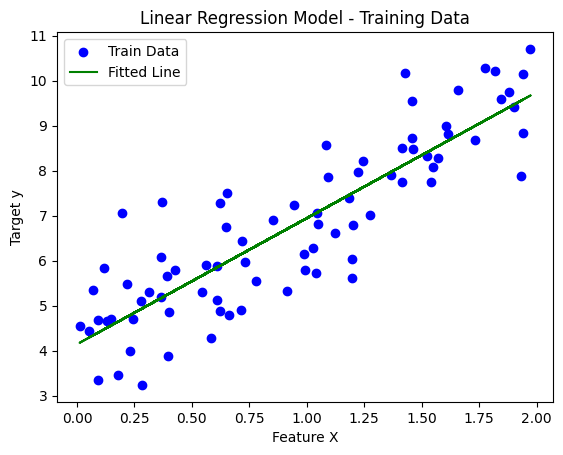

In [33]:
# Step 4: Visualize the fitted line
y_train_pred = model.predict(X_train)

plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.plot(X_train, y_train_pred, color='green', label='Fitted Line')
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.title("Linear Regression Model - Training Data")
plt.legend()
plt.show()


Evaluate the model on the test data

Mean Squared Error on Test Data: 0.6536995137170021


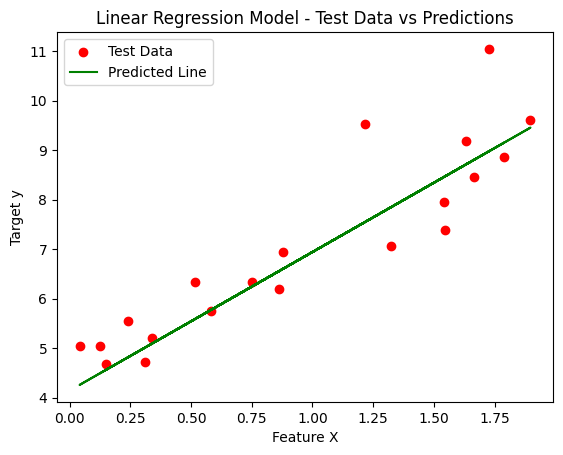

In [34]:
# Step 5: Evaluate the model on the test data
y_test_pred = model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error on Test Data: {mse}")

# Visualize the test data and predictions
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(X_test, y_test_pred, color='green', label='Predicted Line')
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.title("Linear Regression Model - Test Data vs Predictions")
plt.legend()
plt.show()


##The END##